In [5]:
from google.colab import files
uploaded = files.upload()

Saving data_csv.csv to data_csv (1).csv


In [6]:
import pandas as pd
import numpy as np

In [7]:
df = pd.read_csv("data_csv.csv")
df.head()

,CASE_NO_PATIENT'S,A1,A2,A3,A4,A5,A6,A7,A8,A9,...,Global developmental delay/intellectual disability,Social/Behavioural Issues,Childhood Autism Rating Scale,Anxiety_disorder,Sex,Ethnicity,Jaundice,Family_mem_with_ASD,Who_completed_the_test,ASD_traits
0,1,0,0,0,0,0,0,1,1,0,...,Yes,Yes,1,Yes,F,middle eastern,Yes,No,Family Member,No
1,2,1,1,0,0,0,1,1,0,0,...,Yes,Yes,2,Yes,M,White European,Yes,No,Family Member,Yes
2,3,1,0,0,0,0,0,1,1,0,...,Yes,Yes,4,Yes,M,Middle Eastern,Yes,No,Family Member,Yes
3,4,1,1,1,1,1,1,1,1,1,...,Yes,Yes,2,Yes,M,Hispanic,No,No,Family Member,Yes
4,5,1,1,0,1,1,1,1,1,1,...,Yes,Yes,1,Yes,F,White European,No,No,Family Member,Yes


In [8]:
# Fill missing values
df.fillna(df.mean(numeric_only=True), inplace=True)

for col in df.select_dtypes(include='object'):
    df[col].fillna(df[col].mode()[0], inplace=True)

# Encode categorical columns
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

for col in df.select_dtypes(include='object'):
    df[col] = le.fit_transform(df[col])

# Drop ID column
df.drop("CASE_NO_PATIENT'S", axis=1, inplace=True)

/tmp/ipykernel_4301/3616441530.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)


In [9]:
X = df.drop("ASD_traits", axis=1).values
y = df["ASD_traits"].values

In [10]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X = scaler.fit_transform(X)

In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

def fitness(solution):
    idx = np.where(solution == 1)[0]

    if len(idx) == 0:
        return 0

    X_sel = X[:, idx]
    model = LogisticRegression(max_iter=1000)

    return cross_val_score(model, X_sel, y, cv=5, scoring='accuracy').mean()


# BOA parameters
n_butterflies = 20
n_features = X.shape[1]
epochs = 15

population = np.random.randint(0, 2, (n_butterflies, n_features))

best_solution = None
best_score = 0

for epoch in range(epochs):
    for i in range(n_butterflies):
        score = fitness(population[i])

        if score > best_score:
            best_score = score
            best_solution = population[i].copy()

    # update population
    for i in range(n_butterflies):
        for j in range(n_features):
            if np.random.rand() < 0.3:
                population[i][j] = best_solution[j]
            else:
                population[i][j] = np.random.randint(0, 2)

    print(f"Epoch {epoch+1}/{epochs} | Best Accuracy: {best_score:.4f}")

Epoch 1/15 | Best Accuracy: 0.7899
Epoch 2/15 | Best Accuracy: 0.9018
Epoch 3/15 | Best Accuracy: 0.9018
Epoch 4/15 | Best Accuracy: 0.9018
Epoch 5/15 | Best Accuracy: 0.9023
Epoch 6/15 | Best Accuracy: 0.9023
Epoch 7/15 | Best Accuracy: 0.9023
Epoch 8/15 | Best Accuracy: 0.9023
Epoch 9/15 | Best Accuracy: 0.9023
Epoch 10/15 | Best Accuracy: 0.9023
Epoch 11/15 | Best Accuracy: 0.9023
Epoch 12/15 | Best Accuracy: 0.9023
Epoch 13/15 | Best Accuracy: 0.9078
Epoch 14/15 | Best Accuracy: 0.9078
Epoch 15/15 | Best Accuracy: 0.9078


In [12]:
selected_features = np.where(best_solution == 1)[0]

print("Selected Features:", selected_features)
print("Total Selected:", len(selected_features))

X_selected = X[:, selected_features]

Selected Features: [ 0  1  2  3  4  5  6  7 11 12 15 17 19 20 21 22 24]
Total Selected: 17


In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y, test_size=0.2, random_state=42
)

In [14]:
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "SVM": SVC(kernel='rbf'),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Random Forest": RandomForestClassifier(n_estimators=100)
}

results = {}

In [15]:
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    results[name] = acc

    print(f"\n===== {name} =====")
    print("Accuracy:", acc)
    print("\nClassification Report:\n", classification_report(y_test, y_pred))
    print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))


===== Logistic Regression =====
Accuracy: 0.9672544080604534

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.96      0.97       196
           1       0.96      0.98      0.97       201

    accuracy                           0.97       397
   macro avg       0.97      0.97      0.97       397
weighted avg       0.97      0.97      0.97       397


Confusion Matrix:
 [[188   8]
 [  5 196]]

===== SVM =====
Accuracy: 0.9622166246851386

Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.96      0.96       196
           1       0.96      0.97      0.96       201

    accuracy                           0.96       397
   macro avg       0.96      0.96      0.96       397
weighted avg       0.96      0.96      0.96       397


Confusion Matrix:
 [[188   8]
 [  7 194]]

===== KNN =====
Accuracy: 0.9622166246851386

Classification Report:
               precision    reca

In [16]:
best_model_name = max(results, key=results.get)
best_accuracy = results[best_model_name]

print("\n🏆 BEST MODEL:", best_model_name)
print("🎯 ACCURACY:", best_accuracy)


🏆 BEST MODEL: Random Forest
🎯 ACCURACY: 1.0


In [17]:
import joblib

best_model = models[best_model_name]
joblib.dump(best_model, "best_model.pkl")
joblib.dump(selected_features, "selected_features.pkl")
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

Confusion Matrix:
 [[196   0]
 [  0 201]]


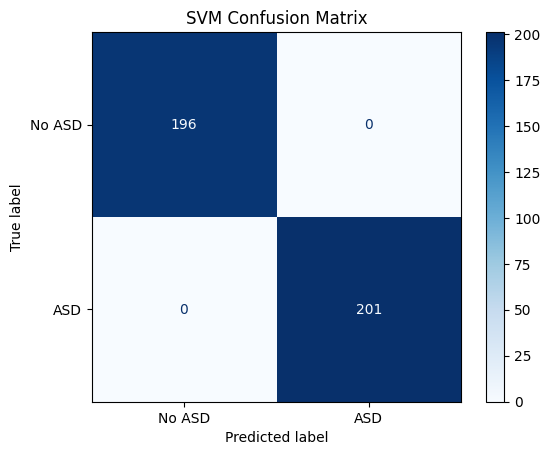

In [18]:
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

# Display confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No ASD", "ASD"])
disp.plot(cmap='Blues')
plt.title("SVM Confusion Matrix")
plt.show()